In [1]:
import pandas as pd
import json
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Tiến hành định nghĩa engine để kết nối dữ liệu và hiển thị
engine = create_engine("sqlite:///../data/sample_strategy/sample_v4.db")

In [3]:
df = pd.read_sql(
    'select x1, x2, x3, x4, x5, x6, x7, x8, x9, y from NearsestSample WHERE TimeDim >= 2010',
    engine
)

In [4]:
tables = ['air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'infrastructure', 'physical_activities', 'tobacco', 'cardiovascular_diseases']
df.columns = tables

In [5]:
df.describe()

,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,infrastructure,physical_activities,tobacco,cardiovascular_diseases
count,1.665000e+04,16603.000000,16932.000000,16932.000000,16932.000000,12450.000000,4939.000000,16932.000000,16932.000000,16932.000000
mean,7.019349e+03,40.354398,22.919354,2.977020,24.373124,8.703438,0.570826,26.175819,23.101925,50.214238
std,2.624625e+05,20.560121,18.930066,1.424073,20.360247,4.255325,0.852852,12.051286,14.527051,30.669230
min,0.000000e+00,0.064401,0.230832,0.700000,2.800000,2.100000,0.000000,2.543773,0.000000,8.593183
25%,5.011050e+01,24.907135,6.682560,1.300000,6.500000,6.000000,0.120000,17.496052,12.000000,32.034064
50%,1.885510e+02,38.958765,21.700000,3.400000,16.000000,8.100000,0.270000,23.848637,22.300000,39.200000
75%,5.759665e+02,52.534967,28.150082,4.100000,42.371031,9.900000,0.710000,33.102670,32.000000,55.300000
max,2.509519e+07,99.257628,93.372130,5.300000,85.359901,29.800000,5.910000,72.202835,77.000000,137.500000


In [6]:
df_dropped = df.drop(columns=["infrastructure"], inplace=True)
df_dropped = df.dropna()
df_dropped.describe()

,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,cardiovascular_diseases
count,1.212500e+04,12125.000000,12125.000000,12125.000000,12125.000000,12125.000000,12125.000000,12125.000000,12125.000000
mean,7.485402e+03,41.370589,21.769799,2.915654,18.411925,8.477435,25.943302,23.465649,53.654623
std,3.037462e+05,19.572123,17.010448,1.423477,17.996540,3.900476,11.854146,14.712074,34.031197
min,0.000000e+00,2.499687,0.236052,0.700000,2.800000,2.100000,3.335438,0.000000,8.656159
25%,5.222100e+01,26.322995,7.257716,1.300000,5.702350,5.900000,17.453480,12.200000,32.429852
50%,1.926470e+02,39.511080,22.000000,3.300000,8.800000,8.000000,23.663223,22.700000,39.800000
75%,5.677640e+02,52.716017,27.000000,4.000000,25.103989,9.800000,32.566956,32.300000,59.600000
max,2.509519e+07,99.257628,92.470789,5.300000,84.117556,29.800000,69.205147,77.000000,137.500000


In [7]:
# Tiến hành vẽ biểu đồ tương quan
corr = df_dropped.corr()

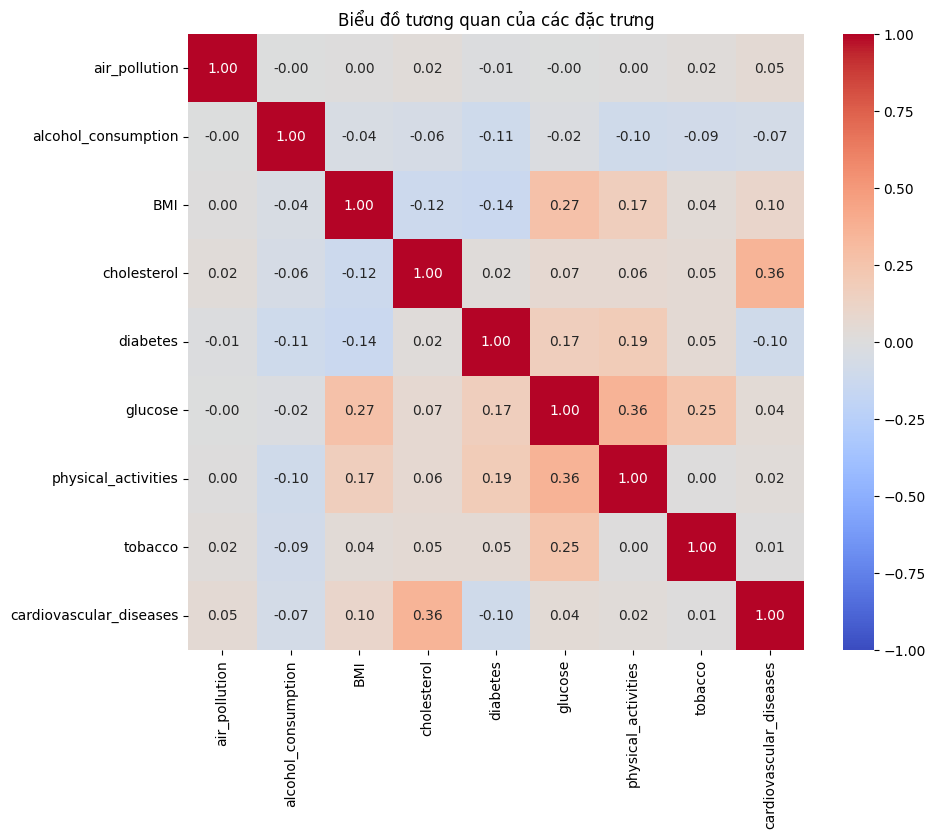

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # hiện giá trị corr
    fmt=".2f",
    cmap="coolwarm",   # thang màu phổ biến cho corr
    vmin=-1, vmax=1,
    square=True
)
plt.title("Biểu đồ tương quan của các đặc trưng")
plt.show()

In [ ]:
# Khởi tạo khung hình với 2 hàng, 4 cột
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle('Phân tích 8 yếu tố ảnh hưởng đến Bệnh Tim Mạch', fontsize=20)

# Lặp qua từng đặc trưng để vẽ
for i, col in enumerate(df.columns):
    print(i, col)
    row = i // 4
    column = i % 4
    
    # Sử dụng boxplot để thấy sự khác biệt về phân phối (phi tuyến)
    sns.boxplot(x=df[col], y=df['cardiovascular_diseases'], ax=axes[row, column], palette='Set2')
    axes[row, column].set_title(f'{col} vs Tim mạch')
    axes[row, column].set_xlabel('Bệnh tim')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\lam01\AppData\Local\Temp\ipykernel_22964\2260700462.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['cardiovascular_diseases'], ax=axes[row, column], palette='Set2')
C:\Users\lam01\AppData\Local\Temp\ipykernel_22964\2260700462.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['cardiovascular_diseases'], ax=axes[row, column], palette='Set2')


KeyboardInterrupt: 